# Firing Rate–Current (F–I) Curve

This notebook studies how the firing rate of a leaky integrate-and-fire neuron changes with the magnitude of a constant injected current.

The subthreshold voltage follows

$$
\tau_m\frac{dV}{dt}
=
-(V-E_L)+R_mI_0.
$$

When the membrane potential reaches $V_{threshold}$, a spike is recorded, the voltage is reset to $V_{reset}$, and the neuron remains at the reset voltage during an absolute refractory period.

The analytical F–I relationship predicts zero firing below the rheobase current and an increasing firing rate above it. This notebook:

- implements a reusable numerical LIF simulator;
- plots the analytical F–I curve;
- validates it using numerical firing-rate measurements;
- examines the rheobase transition;
- and investigates how the refractory period limits the maximum firing rate.

The comparison between the analytical prediction and numerical simulation provides a direct test of the implementation before extending the model to inputs without closed-form solutions.

4.170141784820684
-49.9999


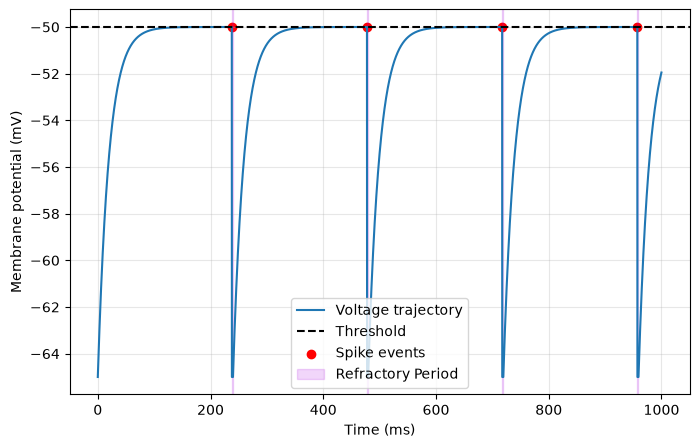

In [81]:
import numpy as np
import matplotlib.pyplot as plt 


def simulate_lif(i0,
                t_end = 1, dt = 1e-4, t_refractory = 2 * 1e-3,
                v_threshold = -50e-3, v_reset = -65e-3, e_l = -65e-3, v0 = -65e-3,
                r_m = 100e6, c_m = 200e-12):

    tau = r_m * c_m
    v_inf = i0 * r_m + e_l

    def dv(v, v_inf, tau):
        return -(v - v_inf)/tau
    
    spike_times = []
    refractory_cond = 0

    time = np.arange(0, t_end, dt)
    v = np.empty_like(time)
    v[0] = v0

    for i in range(time.shape[0] - 1):

        if time[i] < refractory_cond:
            v[i+1] = v[i]
            continue

        dvdt = dv(v[i], v_inf, tau)
        v[i+1] = v[i] + dt * dvdt

        if v[i+1] >= v_threshold:
            v[i+1] = v_reset
            spike_times.append(time[i + 1])
            refractory_cond = time[i+1] + t_refractory

    I_rh = (v_threshold - e_l)/r_m
    spike_times = np.array(spike_times)

    if i0 <= I_rh:
        Frequency = 0

    elif spike_times.size >= 2:
        T_total = np.mean(np.diff(spike_times))
        Frequency = 1 / T_total

    else:
        Frequency = np.nan

    return time, v, spike_times, t_refractory, v_threshold, v_inf, Frequency

time, v, spike_times, t_refractory, v_threshold, v_inf, Frequency = simulate_lif(150.001 * 1e-12)

print(Frequency)
print(v_inf * 1e3)

plt.figure(figsize=(8, 5))
plt.plot(time * 1e3, v * 1e3, label = 'Voltage trajectory')
plt.axhline(v_threshold * 1e3, color = 'black', linestyle = '--', label = 'Threshold')

plt.scatter(
    spike_times * 1e3,
    np.ones_like(spike_times) * v_threshold * 1e3,
      color = 'red',
      label = 'Spike events')

plt.grid(alpha = 0.3)
plt.xlabel('Time (ms)')
plt.ylabel('Membrane potential (mV)')

for j in range(spike_times.shape[0]):
    label = 'Refractory Period' if j == 0 else None 

    plt.axvspan(
        spike_times[j] * 1e3,
        (spike_times[j] + t_refractory) * 1e3, 
        color = "#a903e1",
        label = label,
        alpha = 0.16
        )

plt.legend()
plt.show()

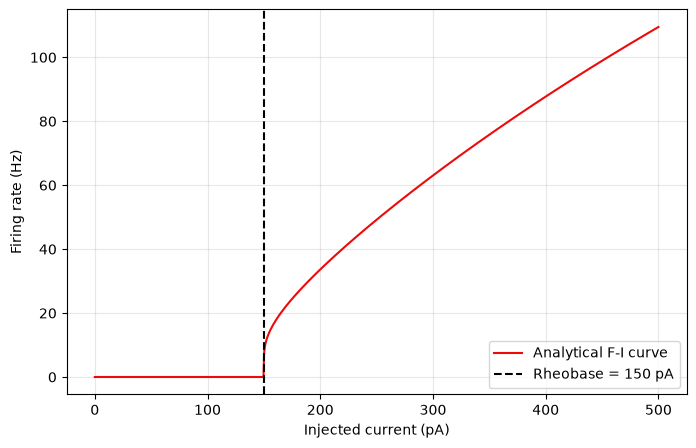

In [82]:
e_l = -65 * 1e-3
v_reset = -65 * 1e-3
v_threshold = -50 * 1e-3
r_m = 100 * 1e6
c_m = 200 * 1e-12
t_refractory = 2 * 1e-3

tau = r_m * c_m
i_rh = (v_threshold - e_l) / r_m


def analytical_firing_rate(i0):

    if i0 <= i_rh:
        return 0.0

    v_inf = i0 * r_m + e_l
    T = tau * np.log((v_reset - v_inf)/(v_threshold - v_inf))
    T_total = T + t_refractory 

    return 1/T_total


currents = np.linspace(0, 500 * 1e-12, 1000)

analytical_rates = np.array([
    analytical_firing_rate(current)
    for current in currents
])


plt.figure(figsize=(8, 5))
plt.plot(currents * 1e12, analytical_rates, label='Analytical F-I curve', color = "#EC0A0A")
plt.axvline(i_rh * 1e12, linestyle = '--', color = 'black', label = f'Rheobase = {i_rh * 1e12:.0f} pA')
plt.xlabel('Injected current (pA)')
plt.ylabel('Firing rate (Hz)')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()


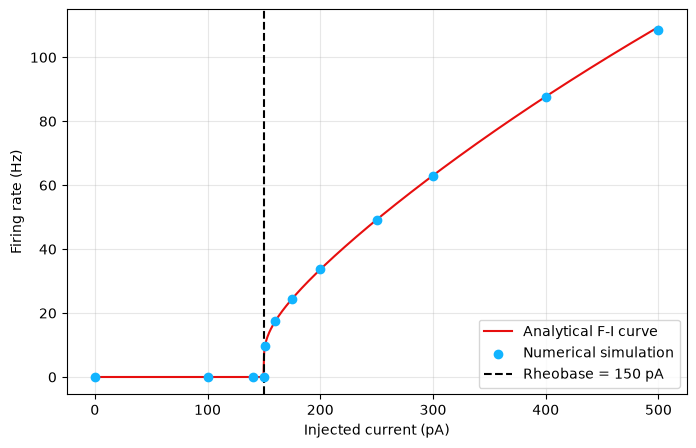

Mean absolute error: 0.0929 Hz
Maximum absolute error: 0.8188 Hz


In [103]:
test_currents = np.array([
    0, 100, 140, 150,
    151, 160, 175, 200,
    250, 300, 400, 500
]) * 1e-12

numerical_rates = []

for current in test_currents:
    time, v, spike_times, t_refractory, v_threshold, v_inf, Frequency = simulate_lif(current, t_end=2, t_refractory=t_refractory, dt = 1e-4)
    numerical_rates.append(Frequency)

numerical_rates = np.array(numerical_rates)

plt.figure(figsize=(8, 5))

plt.plot(
    currents * 1e12,
    analytical_rates,
    color="#E70F0F",
    label='Analytical F-I curve'
)

plt.scatter(
    test_currents * 1e12,
    numerical_rates,
    zorder=3,
    color = "#11B4FF",
    label = 'Numerical simulation'
)

plt.xlabel('Injected current (pA)')
plt.ylabel('Firing rate (Hz)')
plt.axvline(i_rh * 1e12, linestyle = '--', color = 'black', label = f'Rheobase = {i_rh * 1e12:.0f} pA')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

analytical_test_rates = np.array([analytical_firing_rate(current) for current in test_currents])
absolute_errors = np.abs(analytical_test_rates - numerical_rates)

print(f'Mean absolute error: {np.mean(absolute_errors):.4f} Hz')
print(f'Maximum absolute error: {np.max(absolute_errors):.4f} Hz')
